In [11]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans

# 1. Cargar los datos exportados desde R
gdf = gpd.read_file("glasgow_data.geojson")

# 2. Definir el target y las covariables basándonos en tu código de R
# 'log_price' será nuestro target [cite: 134]
target_col = 'log_price'
# Seleccionamos covariables (ajusta según las columnas disponibles en pricedata)
covariate_cols = ['crime', 'rooms', 'sales', 'drive'] # Ejemplo de columnas comunes



In [12]:
# Creamos las transformaciones logarítmicas indicadas en el documento
# Usamos log1p por seguridad ante posibles valores de 0
gdf['log_crime'] = np.log1p(gdf['crime'])
gdf['log_driveshop'] = np.log1p(gdf['driveshop'])

# Añadimos la transformación para las ventas (sales)
gdf['log_sales'] = np.log1p(gdf['sales'])

# Definimos nuestras covariables finales
# Reemplazamos 'sales' por 'log_sales'
covariate_cols_final = ['log_crime', 'rooms', 'log_sales', 'log_driveshop']

# Nota: Si tu modelo soporta variables categóricas directamente (o si ya aplicaste One-Hot Encoding), 
# puedes incluir 'type' en la lista:
# covariate_cols_final = ['log_crime', 'rooms', 'log_sales', 'log_driveshop', 'type']

target = 'log_price'

In [13]:
print(gdf.columns)

Index(['IZ', 'name', 'easting', 'northing', 'price', 'crime', 'rooms', 'sales',
       'driveshop', 'type', 'log_price', 'geometry', 'log_crime',
       'log_driveshop', 'log_sales'],
      dtype='str')


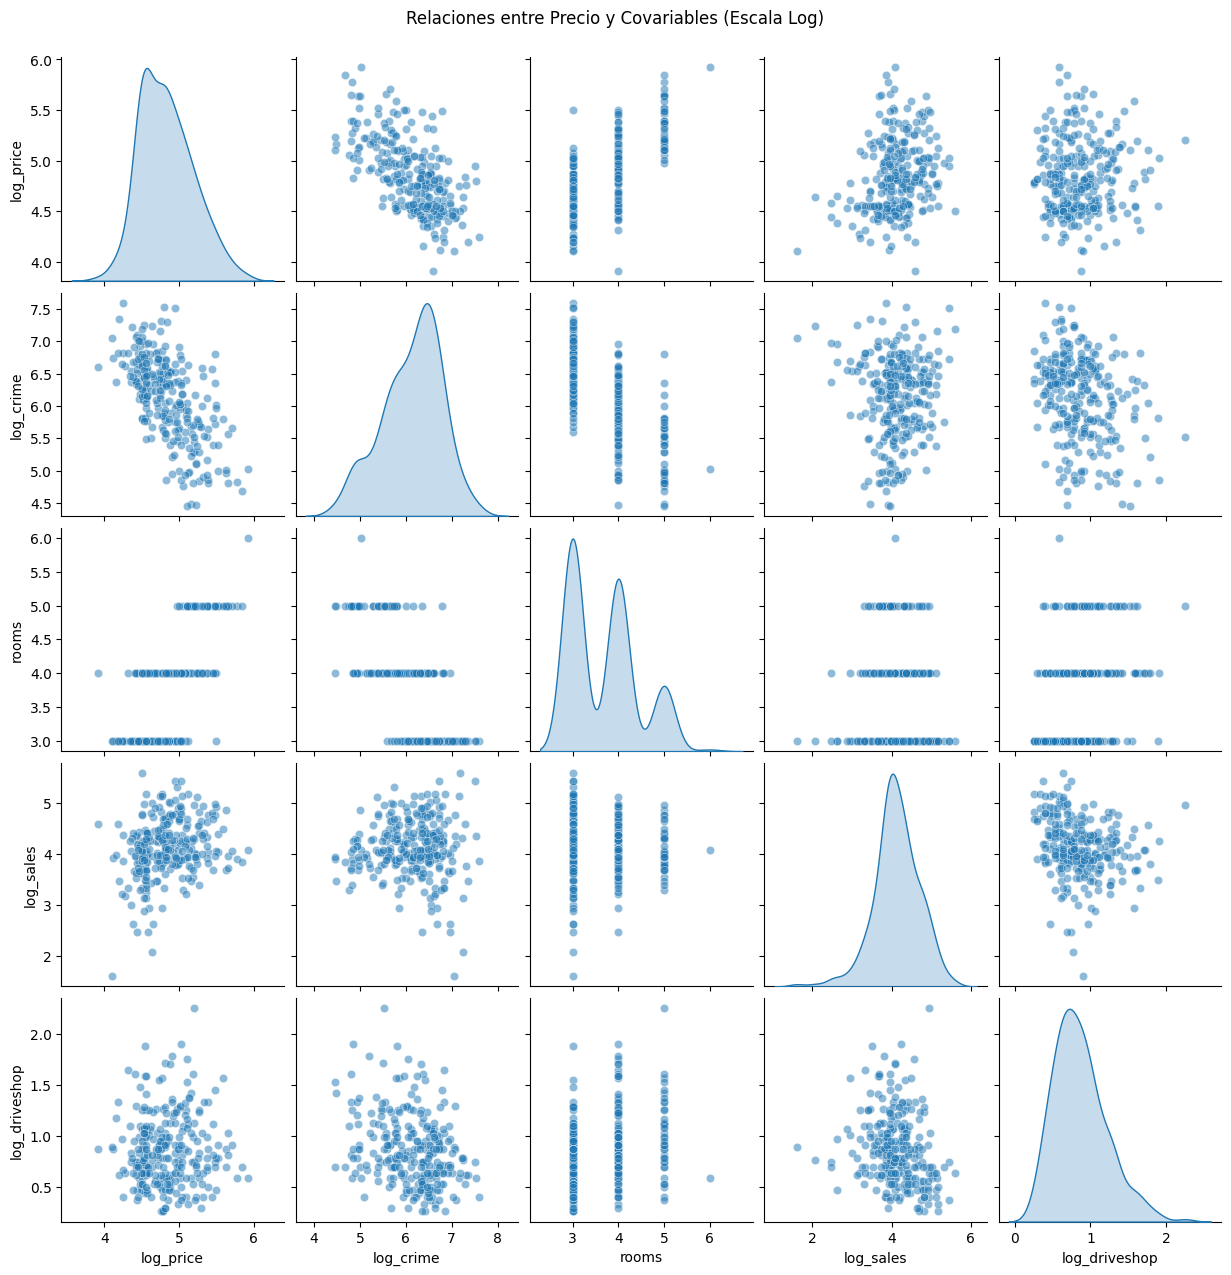

In [15]:
#Visualización en un mapa
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las columnas para el gráfico
cols_to_plot = [target] + covariate_cols_final

# Generamos la matriz de dispersión
sns.pairplot(gdf[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Relaciones entre Precio y Covariables (Escala Log)", y=1.02)
plt.show()

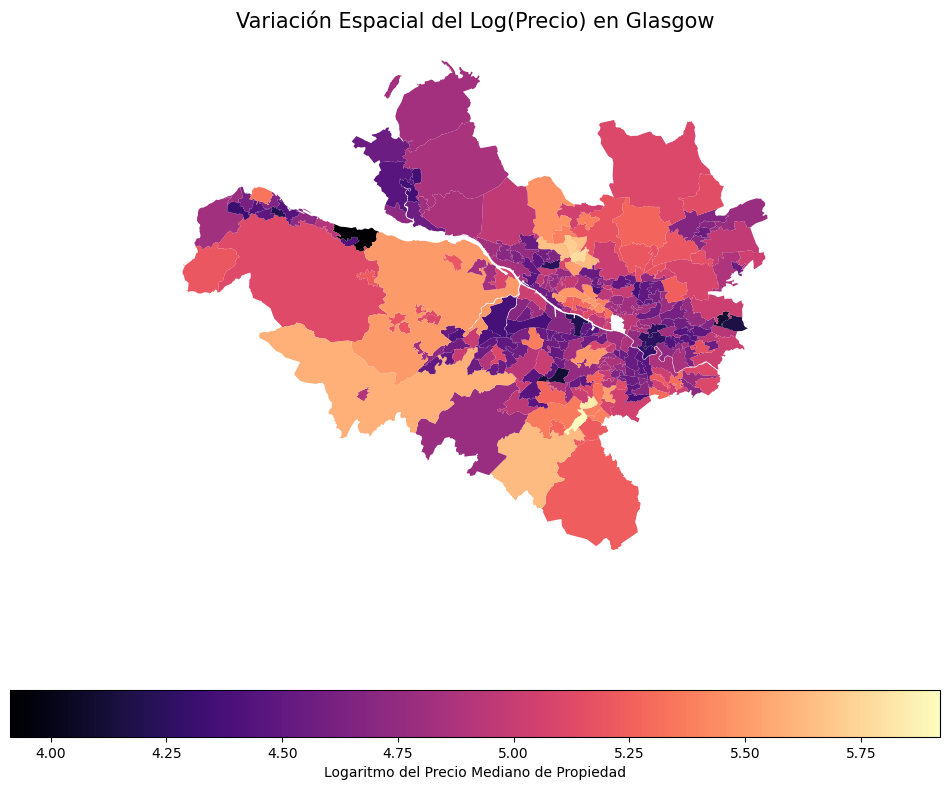

In [16]:
import matplotlib.pyplot as plt

# Configuramos la figura
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Graficamos el GeoDataFrame
# Usamos 'viridis' o 'magma' que son escalas de color perceptualmente uniformes
gdf.plot(column='log_price', 
         cmap='magma', 
         legend=True, 
         legend_kwds={'label': "Logaritmo del Precio Mediano de Propiedad",
                      'orientation': "horizontal"},
         ax=ax)

# Añadimos detalles estéticos
ax.set_title("Variación Espacial del Log(Precio) en Glasgow", fontsize=15)
ax.set_axis_off() # Quitamos los ejes para que parezca un mapa limpio

plt.show()

In [17]:
# Crear el mapa interactivo
# Usamos 'log_price' para el color y mostramos datos útiles en el tooltip
mapa_glasgow = gdf.explore(
    column='log_price',      # Variable que define el color
    cmap='magma',            # Escala de colores (puedes usar 'viridis', 'plasma', etc.)
    tooltip=['name', 'price', 'log_price'],  # Datos que se ven al pasar el ratón
    popup=True,              # Permite hacer clic para ver toda la fila de datos
    legend=True,             # Muestra la barra de escala
    tiles="CartoDB positron" # Fondo de mapa claro y profesional
)

# Mostrar el mapa
mapa_glasgow

Paso 2: Fase 1 de SP-CV – Bloques Espaciales (Algoritmo 1)

Extracción de Centroides: Se calcularon los puntos centrales ($x, y$) de cada polígono de Glasgow para representar su ubicación geográfica de forma numérica.Clustering Jerárquico (AHC): Se aplicó el algoritmo AgglomerativeClustering utilizando únicamente las coordenadas.  Control del Umbral: Se configuró con enlace máximo (linkage='complete') y un umbral de parada de $1500\text{ metros}$. Esto garantiza matemáticamente que ninguna zona dentro de un mismo bloque esté separada de las demás por una distancia mayor al umbral de autocorrelación espacial. 

Paso 3: Fase 2 de SP-CV – Clusterings Independientes

Para evitar que las diferentes escalas numéricas de las variables distorsionen las distancias en los algoritmos, se ejecutaron tres procesos de agrupación separados sobre los bloques promediados:Clustering Geográfico $clusters(L)$: Un modelo $K\text{-Means}$ agrupó los bloques en $5$ grupos según su cercanía física.  Clustering de Entorno $clusters(C)$: Otro $K\text{-Means}$ agrupó los bloques basándose exclusivamente en sus características socioeconómicas y físicas (log_crime, rooms, sales, log_driveshop).  Clustering de Objetivo $clusters(T)$: Un tercer $K\text{-Means}$ agrupó los bloques por la similitud en sus niveles de precios inmobiliarios (log_price). 

Paso 4: Fase 3 de SP-CV – Consenso mediante Grafos (Algoritmo 2)

La Matriz de Partición ($H$): Se compilaron las etiquetas de los tres clusterings anteriores en una matriz binaria cruzada que representa la pertenencia multidimensional de cada bloque.Modelado Bipartito (HBGF): La función hbgf_consensus construyó una matriz de adyacencia ($W$) que conecta los bloques de Glasgow con sus clústeres abstractos correspondientes, dándole el mismo peso analítico (un tercio) a cada dimensión (1/3 geografía, 1/3 variables, 1/3 precio).  Clustering Espectral: Se aplicó un corte sobre este grafo mixto mediante descomposición de vectores propios (estabilizado con $1\text{s}$ en la diagonal principal). Esto agrupó los bloques en los $5$ pliegues finales de validación cruzada (fold_spatial_plus), priorizando la similitud en el espacio de características por encima de la cercanía física.  Desempaquetado: Se expandió la etiqueta del pliegue de cada bloque de regreso a sus polígonos individuales de origen.



$K\text{-Means}$ frente a datos dispersos (El punto débil de Wang)El algoritmo $K\text{-Means}$ (utilizado originalmente por Wang para las tres dimensiones de la Fase 2) se basa en la distancia euclidiana respecto a un centroide. Esto asume implícitamente que los grupos son esféricos, compactos y de densidades similares.

El Clustering Jerárquico Ward (Tu optimización frente a la dispersión)Al cambiar $K\text{-Means}$ por Agglomerative Clustering con enlace Ward para las covariables y los precios, mejoraste la robustez del método ante la dispersión por una razón matemática fundamental:

In [18]:
import time
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from kmodes.kprototypes import KPrototypes

# ==========================================
# 1. CLASES Y FUNCIONES ORIGINALES DE WANG
# ==========================================
class sample_point(object):
    def __init__(self, ID = None, coords = None):
        self.ID = ID
        self.coords = coords

class AHC_cluster(object):
    def __init__(self, points = None, count = None):
        self.points = points
        self.count = count

def env_norm(env_array, cate_num):
    env_num = len(env_array[0,:])
    for env_i in range(env_num - cate_num):
        env_i_max = np.max(env_array[:,env_i])
        env_i_min = np.min(env_array[:,env_i])
        # Evitar división por cero si max == min
        if env_i_max != env_i_min:
            env_array[:,env_i] = (env_array[:,env_i]-env_i_min)/(env_i_max-env_i_min)
        else:
            env_array[:,env_i] = 0
    return env_array

def maxAHClustering(sample_points, autoc_threshold = 1):
    maxAHC_clusters_model = AgglomerativeClustering(distance_threshold = autoc_threshold, n_clusters=None, linkage="complete").fit(sample_points[:,1:])
    maxAHC_counts = maxAHC_clusters_model.n_clusters_
    maxAHC_labels = maxAHC_clusters_model.labels_
    maxAHC_clusters = []
    for i in range(maxAHC_counts):
        maxAHC_i_cluster = AHC_cluster(points = [], count = 0)
        for j in range(len(sample_points)):
            if int(maxAHC_labels[j]) == i:
                point = sample_point(ID = j, coords = [sample_points[j,1], sample_points[j,2]])
                maxAHC_i_cluster.points.append(point)
                maxAHC_i_cluster.count += 1
        maxAHC_clusters.append(maxAHC_i_cluster)
    return maxAHC_clusters

def clusters_var(points, env, tar, cate_num, clusters):
    pure_env = env[:,1:]
    pure_normenv = env_norm(pure_env, cate_num)
    clusters_coords, clusters_normenv, clusters_tar = [], [], []
    
    for cluster in clusters:
        coord_sum = [0,0]
        for point in cluster.points:
            sample_point_ID = int(point.ID)
            coord = points[sample_point_ID, 1:]
            coord_sum = [coord_sum[0]+coord[0], coord_sum[1]+coord[1]]
        coord_avg = [coord_sum[0]/float(cluster.count), coord_sum[1]/float(cluster.count)]
        clusters_coords.append(coord_avg)
        
        cluster_env = []
        for i_env in range(len(pure_normenv[0,:])-cate_num):
            i_env_sum = 0
            for point in cluster.points:
                sample_point_ID = int(point.ID)
                i_env_value = pure_normenv[sample_point_ID, i_env]
                i_env_sum += float(i_env_value)
            cluster_env.append(i_env_sum/float(cluster.count))
            
        for i_env in range(cate_num):
            i_env_array = []
            for point in cluster.points:
                sample_point_ID = int(point.ID)
                i_env_value = pure_normenv[sample_point_ID, -(cate_num-i_env)]
                i_env_array.append(i_env_value)
            i_env_array = np.array(i_env_array)
            i_env_valuecounts = np.bincount(i_env_array.astype(int))
            cluster_env.append(np.argmax(i_env_valuecounts))
        clusters_normenv.append(cluster_env)
        
        tar_sum = 0
        for point in cluster.points:
            sample_point_ID = int(point.ID)
            tar_sum += float(tar[sample_point_ID, -1])
        clusters_tar.append([tar_sum/float(cluster.count)])
        
    return np.array(clusters_coords), np.array(clusters_normenv), np.array(clusters_tar)

# ==========================================
# 2. FUNCIÓN DE CONSENSO (SUSTITUYE A CLUSTERENSEMBLES)
# ==========================================
"""
    Combina múltiples soluciones de clustering (runs) en una partición única de consenso.
    Aplica HBGF (Formulación de Grafo Bipartito Mixto) modelando el problema como la partición de un grafo bipartito.
    
    Parámetros:
    -----------
    cluster_runs : np.array de forma (3, n_blocks)
        Contiene las etiquetas de los 3 clusterings previos para cada bloque:
        - cluster_runs[0]: Etiquetas de Ubicación (L)
        - cluster_runs[1]: Etiquetas de Covariables (C)
        - cluster_runs[2]: Etiquetas del Target (T)
    k_folds : int
        Número de folds finales de validación cruzada deseados.
"""
def hbgf_consensus(cluster_runs, k_folds):

    # 1. IDENTIFICACIÓN DE DIMENSIONES
    # n_blocks es la cantidad total de bloques operativos espaciales creados en la Etapa 1.
    n_blocks = cluster_runs.shape[1]
    # 2. CONSTRUCCIÓN DE LA MATRIZ DE PARTICIÓN (H)
    # Crea una matriz binaria donde cada fila es un bloque y cada columna es un clúster específico.
    # Como hay 3 clusterings de tamaño 'k_folds', el total de columnas es 3 * k_folds.
    H = np.zeros((n_blocks, 3 * k_folds))

    for i in range(n_blocks):
        # Si el bloque 'i' pertenece al clúster 'X' geográfico, se marca con 1.
        H[i, cluster_runs[0][i]] = 1
        # Si pertenece al clúster 'Y' de covariables, se marca con 1 (desplazado en el eje de columnas).
        H[i, k_folds + cluster_runs[1][i]] = 1
        # Si pertenece al clúster 'Z' del target, se marca con 1 (desplazado al final de las columnas).
        H[i, 2 * k_folds + cluster_runs[2][i]] = 1

    #3. CONSTRUCCIÓN DEL GRAFO BIPARTITO MIXTO (Matriz de Adyacencia W)
    # El grafo contiene tanto los bloques individuales como los clústeres abstractos como "nodos".
    # El número total de nodos en el grafo es la suma de bloques + columnas de clústeres.
    total_nodes = n_blocks + (3 * k_folds)
    W = np.zeros((total_nodes, total_nodes))
   # Rellenar la matriz de adyacencia del grafo:
    # Bloques se conectan con Clústeres (esquina superior derecha de la matriz)
    W[:n_blocks, n_blocks:] = H
    # Clústeres se conectan de vuelta con los Bloques (esquina inferior izquierda, simétrica)
    W[n_blocks:, :n_blocks] = H.T
    
    # 4. ESTABILIZACIÓN ALGEBRAICA (Ajuste de Auto-afinidad)
    # Coloca 1s en la diagonal principal. Esto modela que cada nodo está conectado perfectamente
    # consigo mismo, asegurando estabilidad matemática y evitando errores de división por cero
    # al calcular la matriz Laplaciana normalizada en el Clustering Espectral.    
    np.fill_diagonal(W, 1)

    sc = SpectralClustering(n_clusters=k_folds, affinity='precomputed', assign_labels='kmeans', n_init=10, random_state=42)
    final_labels = sc.fit_predict(W)
    return final_labels[:n_blocks]

# ==========================================
# 3. FUNCIÓN PRINCIPAL ADAPTADA A GEODATAFRAMES
# ==========================================
def SP_CV_from_gdf(gdf, covariables_list, target_col, cate_num=0, autoc_threshold=1500, folds_k=5):
    print("Iniciando Spatial+ Cross-Validation...")
    starttime = time.time()
    
   # =========================================================================
    # BLOQUE 1: EXTRACCIÓN Y PREPARACIÓN DE MATRICES NUMÉRICAS PURAS
    # =========================================================================
    # Se generan identificadores secuenciales únicos (IDs) para cada fila en formato float.
    ids = np.arange(len(gdf)).astype(np.float64)
    
    # Se extraen los componentes espaciales calculando los centroides de cada polígono.
    x = gdf.geometry.centroid.x.values.astype(np.float64)
    y = gdf.geometry.centroid.y.values.astype(np.float64)
    
    # Se extraen las matrices independientes para el entorno (covariables) y el objetivo (target).
    envs = gdf[covariables_list].values.astype(np.float64)
    tar = gdf[target_col].values.astype(np.float64)
    
    # Se consolidan todas las columnas en una única matriz maestra de datos.
    samples_data = np.column_stack((ids, x, y, envs, tar))
    
    # Se segmenta la matriz maestra en sub-arreglos específicos manteniendo el ID en la primera columna:
    samples_points = samples_data[:, :3]                                  # [ID, X, Y] (Geografía)
    samples_envs = np.hstack((samples_data[:,:1], samples_data[:, 3:-1])) # [ID, Covariables] (Entorno)
    samples_tars = np.hstack((samples_data[:,:1], samples_data[:, -1:]))  # [ID, Target] (Objetivo)
    
    # =========================================================================
    # BLOQUE 2: FASE 1 - AGRUPAMIENTO JERÁRQUICO ESPACIAL (Algoritmo 1 del Paper)
    # =========================================================================
    print(" -> Fase 1: Agrupamiento Jerárquico Espacial (AHC)")
    
    # Agrupa las muestras contiguas usando Clustering Jerárquico con enlace máximo.
    # El algoritmo se detiene cuando los bloques alcanzan el radio del umbral de autocorrelación (1500m).
    SP_blocks = maxAHClustering(samples_points, autoc_threshold)
    
    # Toma las muestras de cada bloque espacial y calcula sus valores representativos promedio:
    # Coordenadas promedio, covariables promedio (normalizadas) y el target promedio de cada bloque.
    clusters_coords, clusters_normenv, clusters_tar = clusters_var(
        samples_points, samples_envs, samples_tars, cate_num, SP_blocks
    )
    
    # =========================================================================
    # BLOQUE 3: FASE 2 - CLUSTERINGS INDEPENDIENTES (Inicio del Algoritmo 2)
    # =========================================================================
    print(" -> Fase 2: K-Means sobre espacio, entorno y objetivo")
    
    # • Ejecución 1: Agrupamiento por localización (Espacio Geográfico) [clusters(L)]
    # Clasifica la posición de los bloques en 'folds_k' clústeres espaciales basados en sus centroides.
    clusters_points_kmeans = KMeans(n_clusters=folds_k, n_init=10, random_state=42).fit(clusters_coords)
    clusters_points_klabels = clusters_points_kmeans.labels_
    
    # • Ejecución 2: Agrupamiento por características del entorno (Espacio de Atributos) [clusters(C)]
    # Si hay variables categóricas usa K-Prototypes; si no, aplica un KMeans estándar sobre los predictores.
    if cate_num > 0:
        clusters_normenv_klabels = KPrototypes(n_clusters=folds_k, init='Cao', verbose=0).fit_predict(
            clusters_normenv, categorical=list(range(len(clusters_normenv)-cate_num, len(clusters_normenv)))
        )
    else:
        clusters_normenv_kmeans = KMeans(n_clusters=folds_k, n_init=10, random_state=42).fit(clusters_normenv)
        clusters_normenv_klabels = clusters_normenv_kmeans.labels_
        
    # • Ejecución 3: Agrupamiento por comportamiento del mercado (Espacio del Target) [clusters(T)]
    # Agrupa los bloques en función de la similitud en sus valores de la variable objetivo.
    clusters_target_kmeans = KMeans(n_clusters=folds_k, n_init=10, random_state=42).fit(clusters_tar)
    clusters_target_klabels = clusters_target_kmeans.labels_
    
    # =========================================================================
    # BLOQUE 4: FASE 3 - FUNCIÓN DE CONSENSO MEDIANTE GRAFOS (HBGF)
    # =========================================================================
    print(" -> Fase 3: Consenso de Grafos Bipartitos (HBGF)")
    
    # Se compilan las tres matrices de etiquetas de clústeres independientes en un solo arreglo.
    cluster_runs = np.array([clusters_points_klabels, clusters_normenv_klabels, clusters_target_klabels])
    
    # Se invoca la función de consenso HBGF para fusionar las tres soluciones en una sola partición final equilibrada.
    ensemble_clustering_labels = hbgf_consensus(cluster_runs, folds_k)
    
    # =========================================================================
    # BLOQUE 5: DESEMPAQUETADO Y MAPEADO HACIA LAS UNIDADES ORIGINALES
    # =========================================================================
    produced_folds = []
    
    # El consenso se calculó a nivel de bloques operativos. Este bucle mapea esa solución
    # de regreso hacia cada una de las observaciones o áreas poligonales individuales de origen.
    for i in range(len(SP_blocks)):
        cluster_id = i
        fold_label = ensemble_clustering_labels[cluster_id] # Obtiene el fold asignado a este bloque
        
        # Itera sobre todas las celdas o puntos contenidos dentro del bloque actual
        for j in range(SP_blocks[cluster_id].count):
            point_id = SP_blocks[cluster_id].points[j].ID
            origin_point_id = int(samples_points[point_id, 0]) # Rescata el índice original del gdf
            
            # Almacena el emparejamiento entre el ID de la fila original y su fold definitivo de SP-CV
            produced_folds.append({'temp_id': origin_point_id, 'fold_spatial_plus': fold_label})
            
    # Consolida los resultados estructurándolos en un DataFrame de Pandas listo para fusionar.
    df_results = pd.DataFrame(produced_folds)
    print(f"¡Proceso completado en {int(time.time() - starttime)} segundos!")
    
    return df_results

In [19]:
# ==========================================
# 4. EJECUCIÓN SOBRE LOS DATOS DE GLASGOW
# ==========================================

# Asegurarse de que no haya valores nulos que rompan los algoritmos de scikit-learn
gdf_clean = gdf.dropna(subset=['log_crime', 'rooms', 'log_sales', 'log_driveshop', 'log_price', 'type']).copy()

# Definir variables del modelo
covariables = ['log_crime', 'rooms', 'sales', 'log_driveshop']
objetivo = 'log_price'

# Crear un ID temporal para el cruce exacto
gdf_clean['temp_id'] = range(len(gdf_clean))

# Ejecutar el algoritmo Spatial+ (usando 1500 metros como umbral base)
resultados = SP_CV_from_gdf(
    gdf=gdf_clean, 
    covariables_list=covariables, 
    target_col=objetivo, 
    cate_num=0, # Asumimos que todas tus covariables definidas arriba son continuas
    autoc_threshold=2500, 
    folds_k=5
)

# Unir los pliegues resultantes al dataset principal
gdf = gdf.merge(resultados, on='temp_id', how='left') if 'temp_id' in gdf.columns else gdf_clean.merge(resultados, on='temp_id', how='left')

# Limpiar columnas temporales
if 'temp_id' in gdf.columns:
    gdf = gdf.drop(columns=['temp_id'])

# Comprobar la distribución espacial de la muestra
print("\nDistribución de observaciones por pliegue espacial (fold_spatial_plus):")
print(gdf['fold_spatial_plus'].value_counts())

Iniciando Spatial+ Cross-Validation...
 -> Fase 1: Agrupamiento Jerárquico Espacial (AHC)
 -> Fase 2: K-Means sobre espacio, entorno y objetivo
 -> Fase 3: Consenso de Grafos Bipartitos (HBGF)
¡Proceso completado en 0 segundos!

Distribución de observaciones por pliegue espacial (fold_spatial_plus):
fold_spatial_plus
2    91
4    67
3    58
0    36
1    18
Name: count, dtype: int64


In [20]:
import numpy as np
import pandas as pd
from libpysal.weights import Queen
from spreg import ML_Lag

# 1. Variables a utilizar
target_col = 'log_price'
covariables_list = ['log_crime', 'rooms', 'sales', 'log_driveshop']
todas_las_columnas = [target_col] + covariables_list + ['fold_spatial_plus', 'geometry']

# 2. LIMPIEZA CRÍTICA DE NaN E INFINITOS
gdf_limpio = gdf[todas_las_columnas].replace([np.inf, -np.inf], np.nan)

filas_antes = len(gdf_limpio)
gdf_limpio = gdf_limpio.dropna(subset=[target_col] + covariables_list)
filas_despues = len(gdf_limpio)

if filas_antes != filas_despues:
    print(f"⚠️ Se eliminaron {filas_antes - filas_despues} áreas de Glasgow por valores inválidos.\n")

gdf_limpio = gdf_limpio.reset_index(drop=True)

# 3. Re-estructurar los vectores de datos limpios
y = gdf_limpio[target_col].values.reshape(-1, 1)
X = gdf_limpio[covariables_list].values
folds = gdf_limpio['fold_spatial_plus'].values

# Listas para almacenar las métricas
train_errors = []
val_errors = []
rho_values = []

# Lista para construir la tabla final
resultados_tabla = []
print("--- Iniciando Validación Cruzada SP-CV para Modelo SAR ---")

# 4. Loop de Validación Cruzada
for fold_idx in range(5):
    train_mask = (folds != fold_idx)
    val_mask = (folds == fold_idx)
    
    gdf_train = gdf_limpio[train_mask]
    
    y_train = y[train_mask]
    X_train = X[train_mask]
    y_val = y[val_mask]
    X_val = X[val_mask]
    
    # Matriz de pesos para el entrenamiento
    # Nota: Al aislar un pliegue pueden quedar 'islas' desconectadas. 
    # silence_warnings=True evita que la consola se llene de avisos de libpysal
    w_train = Queen.from_dataframe(gdf_train, use_index=False, silence_warnings=True)
    w_train.transform = 'R'  # Estandarizada por filas
    
    # Entrenamiento del Modelo SAR
    model_sar = ML_Lag(y_train, X_train, w=w_train, name_y=target_col, name_x=covariables_list)
    rho_val = float(model_sar.rho) # Asegurar que sea float
    rho_values.append(rho_val)
    
    # --- EVALUACIÓN EN ENTRENAMIENTO (IN-SAMPLE) ---
    # PySAL guarda la predicción in-sample (incluye el rezago espacial W*y) en model_sar.predy
    train_rmse = np.sqrt(np.mean((y_train - model_sar.predy) ** 2))
    train_errors.append(train_rmse)
    
    # --- EVALUACIÓN EN VALIDACIÓN (OUT-OF-SAMPLE) ---
    # Extraemos los coeficientes. spreg guarda [constante, beta1, beta2..., rho]
    # Usamos los betas estructurales para predecir sobre las zonas no vistas
    beta_coefficients = model_sar.betas[:-1] 
    predictions_val = np.dot(X_val, beta_coefficients[1:]) + beta_coefficients[0]
    
    val_rmse = np.sqrt(np.mean((y_val - predictions_val) ** 2))
    val_errors.append(val_rmse)

    # Guardar métricas del fold actual para la tabla
    resultados_tabla.append({
        'Fold': f"Fold {fold_idx}",
        'RMSE_Train': train_rmse,
        'RMSE_Val': val_rmse,
        'Overfitting_Gap': val_rmse - train_rmse,
        'Rho': rho_val
    })

    # Imprimir el rendimiento de la iteración actual
    #print(f"Fold {fold_idx}:")
    #print(f"  -> RMSE Entrenamiento : {train_rmse:.4f}")
    #print(f"  -> RMSE Validación    : {val_rmse:.4f}")
    #print(f"  -> Brecha (Overfitting): {val_rmse - train_rmse:.4f}")
    #print(f"  -> Rho estimado (ρ)   : {model_sar.rho:.4f}\n")


# 5. Reporte Final (Generación de Tabla)
# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados_tabla)

# Calcular promedios para la fila "Total"
fila_total = {
    'Fold': 'Promedio (Total)',
    'RMSE_Train': np.mean(train_errors),
    'RMSE_Val': np.mean(val_errors),
    'Overfitting_Gap': np.mean(val_errors) - np.mean(train_errors),
    'Rho': np.mean(rho_values)
}

# Añadir la fila total al DataFrame
df_resultados = pd.concat([df_resultados, pd.DataFrame([fila_total])], ignore_index=True)

# Imprimir la tabla con formato redondeado a 4 decimales
print("\n=== RESULTADOS DEL MODELO SAR (SP-CV) ===")
# to_string permite controlar el formato de visualización en consola de manera limpia
print(df_resultados.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados_tabla)
print("=== RESUMEN FINAL DEL MODELO SAR (SP-CV) ===")
print(f"RMSE Entrenamiento Promedio: {np.mean(train_errors):.4f}")
print(f"RMSE Validación Promedio:    {np.mean(val_errors):.4f}")
print(f"Diferencia (Gap):            {np.mean(val_errors) - np.mean(train_errors):.4f}")
print(f"Estabilidad de Rho Promedio: {np.mean(rho_values):.4f}")

--- Iniciando Validación Cruzada SP-CV para Modelo SAR ---
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag

=== RESULTADOS DEL MODELO SAR (SP-CV) ===
            Fold  RMSE_Train  RMSE_Val  Overfitting_Gap    Rho
          Fold 0      0.2004    2.1294           1.9289 0.4327
          Fold 1      0.2168    1.4097           1.1929 0.2202
          Fold 2      0.2212    0.8394           0.6182 0.1366
          Fold 3      0.2073    1.7744           1.5671 0.3779
          Fold 4      0.2038    1.2591           1.0553 0.2901
Promedio (Total)      0.2099    1.4824           1.2725 0.2915
=== RESUMEN FINAL DEL MODELO SAR (SP-CV) ===
RMSE Entrenamiento Promedio: 0.2099
RMSE Validación Promedio:    1.4824
Diferencia (Gap):            1.2725
Estabilidad de Rho Promedio: 0.2915


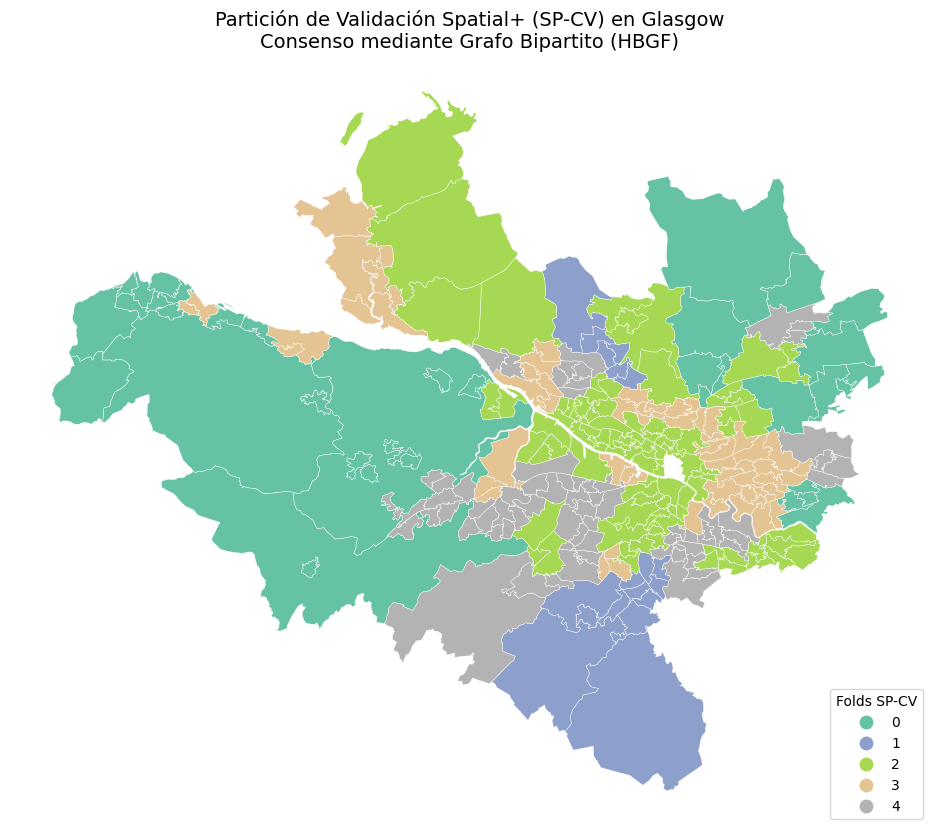

In [21]:
import matplotlib.pyplot as plt

# Configuramos el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Graficamos los polígonos de Glasgow coloreados por su número de Fold
gdf.plot(
    column='fold_spatial_plus', 
    cmap='Set2',          # Paleta de colores cualitativa y limpia
    categorical=True, 
    legend=True, 
    legend_kwds={'title': "Folds SP-CV", 'loc': 'lower right'},
    edgecolor='white',    # Línea blanca fina para separar los distritos
    linewidth=0.3,
    ax=ax
)

plt.title("Partición de Validación Spatial+ (SP-CV) en Glasgow\nConsenso mediante Grafo Bipartito (HBGF)", fontsize=14)
plt.axis('off') # Quitamos los ejes para que luzca como un mapa limpio
plt.show()